In [83]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,BatchNormalization,Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [38]:
df=pd.read_csv(r'C:\Users\amank\Downloads\DEEP LEARNING ANN\Rainfall.csv')
df.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [39]:
df.drop(columns=['day'],inplace=True)

In [44]:
df.isnull().sum()

pressure                  0
maxtemp                   0
temparature               0
mintemp                   0
dewpoint                  0
humidity                  0
cloud                     0
rainfall                  0
sunshine                  0
         winddirection    0
windspeed                 0
dtype: int64

In [ ]:
#   WHEN U FIND DUPLICATED VALUES USE THIS  REMOVES NAN VALUES IN THE DATASET

#   IF WANNA FILLNA VALUES USE THIS 

# x=x.fillna(x.mean,median,mode())
# y=y.fillna(x.mean,median,mode()[0])

In [43]:
df.dropna(inplace=True)

In [ ]:
#                ALWAYS CHECK DATATYPES BEST USE INFO FOR ALL INFOR ALL AT ONCE

In [48]:
df.info()

<class 'pandas.DataFrame'>
Index: 365 entries, 0 to 365
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   pressure                365 non-null    float64
 1   maxtemp                 365 non-null    float64
 2   temparature             365 non-null    float64
 3   mintemp                 365 non-null    float64
 4   dewpoint                365 non-null    float64
 5   humidity                365 non-null    int64  
 6   cloud                   365 non-null    int64  
 7   rainfall                365 non-null    int64  
 8   sunshine                365 non-null    float64
 9            winddirection  365 non-null    float64
 10  windspeed               365 non-null    float64
dtypes: float64(8), int64(3)
memory usage: 34.2 KB


In [ ]:
#   MAP THE COLUMN IF HAVING SRING TO INT

In [47]:
df['rainfall']=df['rainfall'].map({'yes':1,'no':0})

In [49]:
df.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,19.9,18.3,16.8,13.1,72,49,1,9.3,80.0,26.3
1,1022.0,21.7,18.9,17.2,15.6,81,83,1,0.6,50.0,15.3
2,1019.7,20.3,19.3,18.0,18.4,95,91,1,0.0,40.0,14.2
3,1018.9,22.3,20.6,19.1,18.8,90,88,1,1.0,50.0,16.9
4,1015.9,21.3,20.7,20.2,19.9,95,81,1,0.0,40.0,13.7


In [ ]:
#      FEATURE SELECTION X AND Y

In [50]:
x=df.drop(columns=['rainfall'])
y=df['rainfall']

In [51]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
#                         DATA SCALING 

In [68]:
scaled=StandardScaler()

In [69]:
x_train = scaled.fit_transform(x_train)
x_test = scaled.transform(x_test)

In [ ]:
#                         DO CHECK THE SHAPE OF THE DATA.

In [70]:
x.shape,y.shape

((365, 10), (365,))

In [ ]:
#                       MODEL SELECTION 

In [71]:
model=Sequential()

In [93]:
model.add(Dense(556,activation='relu',input_dim=(10)))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Dense(256,activation='relu'))  # CAN DO THIS WAS AS WELL  model.add(Dense(128)) SELECT RELU DEFAULT.
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Dense(128,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(64,activation='relu'))

model.add(Dense(1,activation='sigmoid'))

c:\Users\amank\Downloads\DEEP LEARNING ANN\.Deelearn\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#                                     COMPILE 

In [94]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
#                               EARLY STOPPING 

In [95]:
early=EarlyStopping(monitor='val_loss',patience=4,restore_best_weights=True)

In [ ]:
#                                     FIT AND PREDICT 

In [ ]:
history=model.fit(x_train,y_train,batch_size=32,epochs=50,validation_split=0.2,verbose=1,callbacks=[early])

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 64s 654ms/step - accuracy: 0.5751 - loss: 0.7836 - val_accuracy: 0.7119 - val_loss: 0.6914
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 268ms/step - accuracy: 0.9056 - loss: 0.3252 - val_accuracy: 0.7119 - val_loss: 0.6810
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step - accuracy: 0.8670 - loss: 0.3468 - val_accuracy: 0.7119 - val_loss: 0.6581
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 241ms/step - accuracy: 0.9227 - loss: 0.2398 - val_accuracy: 0.7119 - val_loss: 0.6467
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 159ms/step - accuracy: 0.8927 - loss: 0.2432 - val_accuracy: 0.7119 - val_loss: 0.6468
Epoch 6/50
6/8 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9375 - loss: 0.1938

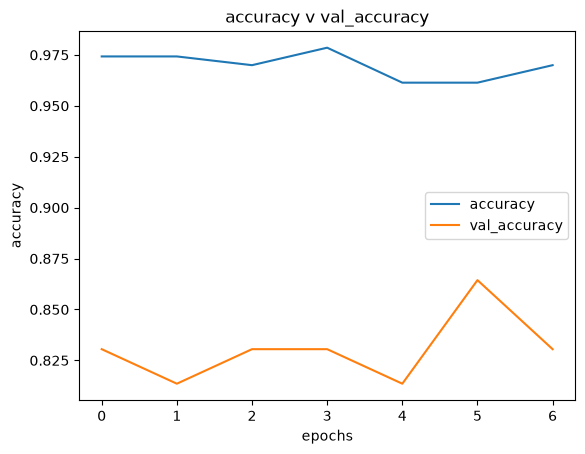

In [87]:
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.title('accuracy v val_accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

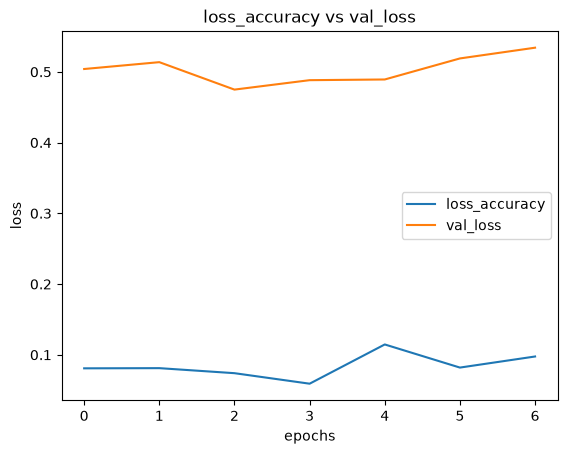

In [88]:
plt.plot(history.history['loss'],label='loss_accuracy')
plt.plot(history.history['val_loss'],label='val_loss')
plt.title('loss_accuracy vs val_loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [92]:
loss, accuracy = model.evaluate(x_test, y_test)
print(loss)
print(accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.7808 - loss: 0.5404
0.5403763651847839
0.7808219194412231


In [ ]:
#                                      END